<a href="https://colab.research.google.com/github/zubaeteee20210205109-droid/Trial/blob/main/new.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os

train_dir = "/content/drive/MyDrive/Skin cancer ISIC The International Skin Imaging Collaboration/Train"
test_dir  = "/content/drive/MyDrive/Skin cancer ISIC The International Skin Imaging Collaboration/Test"

print("Train Classes:")
print(os.listdir(train_dir))

print("\nTest Classes:")
print(os.listdir(test_dir))

Train Classes:
['vascular lesion', 'seborrheic keratosis', 'squamous cell carcinoma', 'pigmented benign keratosis', 'melanoma', 'nevus', 'dermatofibroma', 'basal cell carcinoma', 'actinic keratosis']

Test Classes:
['nevus', 'basal cell carcinoma', 'vascular lesion', 'pigmented benign keratosis', 'seborrheic keratosis', 'squamous cell carcinoma', 'melanoma', 'dermatofibroma', 'actinic keratosis']


In [2]:
import os

train_dir = "/content/drive/MyDrive/Skin cancer ISIC The International Skin Imaging Collaboration/Train"
test_dir  = "/content/drive/MyDrive/Skin cancer ISIC The International Skin Imaging Collaboration/Test"

print("TRAIN DATASET")
for cls in sorted(os.listdir(train_dir)):
    cls_path = os.path.join(train_dir, cls)
    if os.path.isdir(cls_path):
        print(cls, len(os.listdir(cls_path)))

print("\nTEST DATASET")
for cls in sorted(os.listdir(test_dir)):
    cls_path = os.path.join(test_dir, cls)
    if os.path.isdir(cls_path):
        print(cls, len(os.listdir(cls_path)))

TRAIN DATASET
actinic keratosis 114
basal cell carcinoma 376
dermatofibroma 95
melanoma 438
nevus 357
pigmented benign keratosis 462
seborrheic keratosis 77
squamous cell carcinoma 181
vascular lesion 139

TEST DATASET
actinic keratosis 16
basal cell carcinoma 16
dermatofibroma 16
melanoma 16
nevus 16
pigmented benign keratosis 16
seborrheic keratosis 3
squamous cell carcinoma 16
vascular lesion 3


In [3]:
from PIL import Image
import os

train_dir = "/content/drive/MyDrive/Skin cancer ISIC The International Skin Imaging Collaboration/Train"

for cls in os.listdir(train_dir):
    cls_path = os.path.join(train_dir, cls)

    if os.path.isdir(cls_path):
        img_name = os.listdir(cls_path)[0]
        img_path = os.path.join(cls_path, img_name)

        img = Image.open(img_path)

        print("Class:", cls)
        print("Image Size:", img.size)
        break

Class: vascular lesion
Image Size: (600, 450)


In [4]:
import os

train_dir = "/content/drive/MyDrive/Skin cancer ISIC The International Skin Imaging Collaboration/Train"

classes = sorted([
    d for d in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, d))
])

print("Classes:", classes)
print("Number of Classes:", len(classes))

Classes: ['actinic keratosis', 'basal cell carcinoma', 'dermatofibroma', 'melanoma', 'nevus', 'pigmented benign keratosis', 'seborrheic keratosis', 'squamous cell carcinoma', 'vascular lesion']
Number of Classes: 9


In [5]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [6]:
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
print(tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.20.0
Num GPUs Available: 0
[]


In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_dir = "/content/drive/MyDrive/Skin cancer ISIC The International Skin Imaging Collaboration/Train"

datagen = ImageDataGenerator(validation_split=0.2)

train_gen = datagen.flow_from_directory(
    train_dir,
    target_size=(300,300),
    batch_size=16,
    class_mode='categorical',
    subset='training'
)

val_gen = datagen.flow_from_directory(
    train_dir,
    target_size=(300,300),
    batch_size=16,
    class_mode='categorical',
    subset='validation'
)

print("Train Samples:", train_gen.samples)
print("Validation Samples:", val_gen.samples)
print("Class Indices:")
print(train_gen.class_indices)

Found 1795 images belonging to 9 classes.
Found 444 images belonging to 9 classes.
Train Samples: 1795
Validation Samples: 444
Class Indices:
{'actinic keratosis': 0, 'basal cell carcinoma': 1, 'dermatofibroma': 2, 'melanoma': 3, 'nevus': 4, 'pigmented benign keratosis': 5, 'seborrheic keratosis': 6, 'squamous cell carcinoma': 7, 'vascular lesion': 8}


In [8]:
import os

test_dir = "/content/drive/MyDrive/Skin cancer ISIC The International Skin Imaging Collaboration/Test"

total = 0

for cls in sorted(os.listdir(test_dir)):
    n = len(os.listdir(os.path.join(test_dir, cls)))
    total += n
    print(cls, n)

print("\nTotal Test Images =", total)

actinic keratosis 16
basal cell carcinoma 16
dermatofibroma 16
melanoma 16
nevus 16
pigmented benign keratosis 16
seborrheic keratosis 3
squamous cell carcinoma 16
vascular lesion 3

Total Test Images = 118


In [1]:
!nvidia-smi

Fri Jun 12 16:45:13 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   58C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_dir = "/content/drive/MyDrive/Skin cancer ISIC The International Skin Imaging Collaboration/Train"

temp_gen = ImageDataGenerator(validation_split=0.2)

train_gen = temp_gen.flow_from_directory(
    train_dir,
    target_size=(300,300),
    batch_size=16,
    class_mode='categorical',
    subset='training',
    shuffle=False
)

print("Class Indices:")
print(train_gen.class_indices)

print("\nSamples Per Class:")
import numpy as np

class_counts = np.bincount(train_gen.classes)

for cls, idx in train_gen.class_indices.items():
    print(f"{cls}: {class_counts[idx]}")

Found 1795 images belonging to 9 classes.
Class Indices:
{'actinic keratosis': 0, 'basal cell carcinoma': 1, 'dermatofibroma': 2, 'melanoma': 3, 'nevus': 4, 'pigmented benign keratosis': 5, 'seborrheic keratosis': 6, 'squamous cell carcinoma': 7, 'vascular lesion': 8}

Samples Per Class:
actinic keratosis: 92
basal cell carcinoma: 301
dermatofibroma: 76
melanoma: 351
nevus: 286
pigmented benign keratosis: 370
seborrheic keratosis: 62
squamous cell carcinoma: 145
vascular lesion: 112


In [17]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.applications.efficientnet import preprocess_input

from sklearn.utils.class_weight import compute_class_weight

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [18]:
from tensorflow.keras import mixed_precision

mixed_precision.set_global_policy("mixed_float16")

print(mixed_precision.global_policy())

<DTypePolicy "mixed_float16">


In [19]:
train_dir = "/content/drive/MyDrive/Skin cancer ISIC The International Skin Imaging Collaboration/Train"

test_dir = "/content/drive/MyDrive/Skin cancer ISIC The International Skin Imaging Collaboration/Test"

IMG_SIZE = (300, 300)
BATCH_SIZE = 16
NUM_CLASSES = 9

In [20]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.20,
    rotation_range=25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.20,
    horizontal_flip=True,
    fill_mode="nearest"
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [21]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

print(train_generator.class_indices)

Found 1795 images belonging to 9 classes.
Found 444 images belonging to 9 classes.
Found 118 images belonging to 9 classes.
{'actinic keratosis': 0, 'basal cell carcinoma': 1, 'dermatofibroma': 2, 'melanoma': 3, 'nevus': 4, 'pigmented benign keratosis': 5, 'seborrheic keratosis': 6, 'squamous cell carcinoma': 7, 'vascular lesion': 8}


In [22]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(2.167874396135266), 1: np.float64(0.6626061277224068), 2: np.float64(2.624269005847953), 3: np.float64(0.5682177904400126), 4: np.float64(0.6973581973581974), 5: np.float64(0.539039039039039), 6: np.float64(3.216845878136201), 7: np.float64(1.3754789272030652), 8: np.float64(1.7807539682539681)}


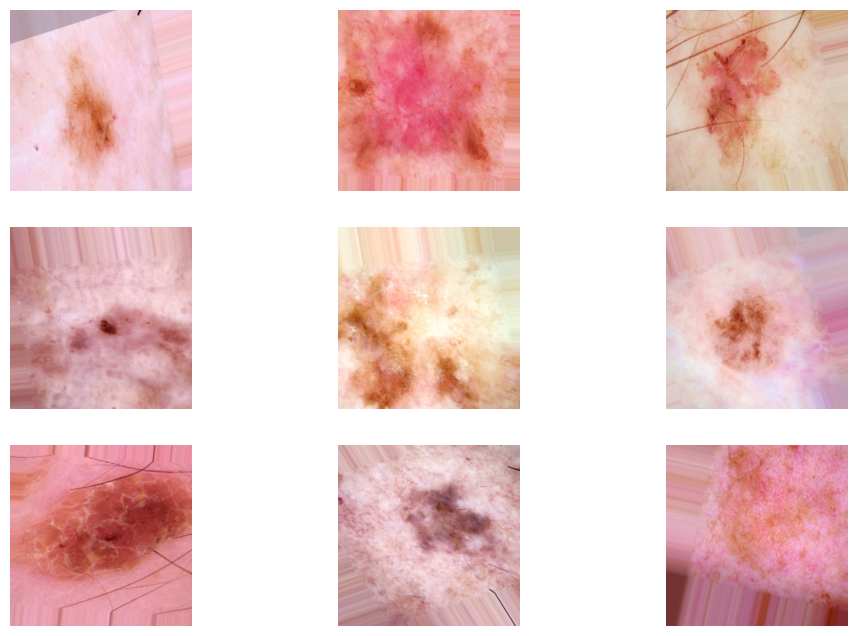

In [23]:
x_batch, y_batch = next(train_generator)

plt.figure(figsize=(12,8))

for i in range(9):
    plt.subplot(3,3,i+1)

    img = x_batch[i]

    img = (img - img.min()) / (img.max() - img.min())

    plt.imshow(img)

    plt.axis("off")

plt.show()

In [24]:
base_model = EfficientNetB3(
    weights="imagenet",
    include_top=False,
    input_shape=(300,300,3)
)

base_model.trainable = False

inputs = tf.keras.Input(shape=(300,300,3))

x = base_model(inputs, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.BatchNormalization()(x)

x = layers.Dropout(0.5)(x)

x = layers.Dense(
    512,
    activation="relu"
)(x)

x = layers.BatchNormalization()(x)

x = layers.Dropout(0.4)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    dtype="float32"
)(x)

model = Model(inputs, outputs)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 10, 10, 1536)   │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1536)           │         6,144 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       786,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 9)              │         4,617 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,583,288 (44.19 MB)

 Trainable params: 795,657 (3.04 MB)

 Non-trainable params: 10,787,631 (41.15 MB)

In [25]:
loss_fn = tf.keras.losses.CategoricalCrossentropy(
    label_smoothing=0.1
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=3e-4
    ),
    loss=loss_fn,
    metrics=["accuracy"]
)

In [26]:
checkpoint = ModelCheckpoint(
    "best_skin_cancer_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

earlystop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=4,
    verbose=1
)

callbacks = [
    checkpoint,
    earlystop,
    reduce_lr
]

In [27]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 741ms/step - accuracy: 0.1554 - loss: 3.0889
Epoch 1: val_accuracy improved from None to 0.31081, saving model to best_skin_cancer_model.keras

Epoch 1: finished saving model to best_skin_cancer_model.keras
113/113 ━━━━━━━━━━━━━━━━━━━━ 227s 1s/step - accuracy: 0.1972 - loss: 2.8632 - val_accuracy: 0.3108 - val_loss: 1.9869 - learning_rate: 3.0000e-04
Epoch 2/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 546ms/step - accuracy: 0.2861 - loss: 2.4170
Epoch 2: val_accuracy improved from 0.31081 to 0.32432, saving model to best_skin_cancer_model.keras

Epoch 2: finished saving model to best_skin_cancer_model.keras
113/113 ━━━━━━━━━━━━━━━━━━━━ 79s 697ms/step - accuracy: 0.2975 - loss: 2.3795 - val_accuracy: 0.3243 - val_loss: 2.0148 - learning_rate: 3.0000e-04
Epoch 3/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 529ms/step - accuracy: 0.3205 - loss: 2.3385
Epoch 3: val_accuracy did not improve from 0.32432
113/113 ━━━━━━━━━━━━━━━━━━━━ 75s 669ms/step - accuracy: 0.3142 -

In [28]:
base_model.trainable = True

for layer in base_model.layers[:-80]:
    layer.trainable = False

print("Trainable Layers:")

trainable_count = 0

for layer in model.layers:
    if layer.trainable:
        trainable_count += 1

print(trainable_count)

Trainable Layers:
9


In [29]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss=tf.keras.losses.CategoricalCrossentropy(
        label_smoothing=0.1
    ),
    metrics=["accuracy"]
)

In [30]:
fine_tune_epochs = 25

history_fine = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=fine_tune_epochs,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/25
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3405 - loss: 1.9783
Epoch 1: val_accuracy did not improve from 0.50901
113/113 ━━━━━━━━━━━━━━━━━━━━ 308s 2s/step - accuracy: 0.3415 - loss: 2.0784 - val_accuracy: 0.4347 - val_loss: 1.8042 - learning_rate: 1.0000e-05
Epoch 2/25
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 516ms/step - accuracy: 0.3288 - loss: 1.9632
Epoch 2: val_accuracy did not improve from 0.50901
113/113 ━━━━━━━━━━━━━━━━━━━━ 79s 699ms/step - accuracy: 0.3443 - loss: 1.9767 - val_accuracy: 0.4257 - val_loss: 1.7866 - learning_rate: 1.0000e-05
Epoch 3/25
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 511ms/step - accuracy: 0.3522 - loss: 1.9817
Epoch 3: val_accuracy did not improve from 0.50901
113/113 ━━━━━━━━━━━━━━━━━━━━ 73s 648ms/step - accuracy: 0.3476 - loss: 1.9862 - val_accuracy: 0.4144 - val_loss: 1.8724 - learning_rate: 1.0000e-05
Epoch 4/25
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 525ms/step - accuracy: 0.3863 - loss: 1.9273
Epoch 4: val_accuracy did not improve from 0.50901

Epoc

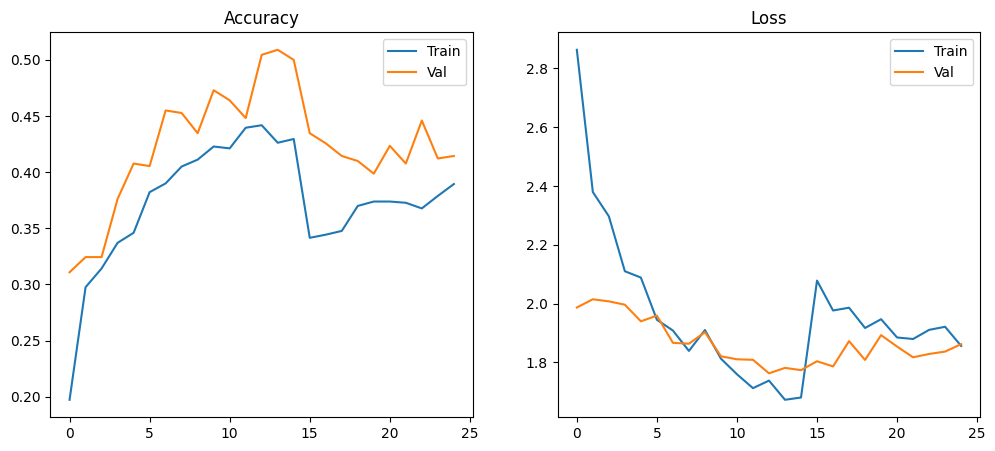

In [31]:

acc = history.history['accuracy'] + history_fine.history['accuracy']
val_acc = history.history['val_accuracy'] + history_fine.history['val_accuracy']
loss = history.history['loss'] + history_fine.history['loss']
val_loss = history.history['val_loss'] + history_fine.history['val_loss']

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(acc)
plt.plot(val_acc)
plt.legend(['Train','Val'])
plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(loss)
plt.plot(val_loss)
plt.legend(['Train','Val'])
plt.title('Loss')
plt.show()


In [32]:
best_model=tf.keras.models.load_model('best_skin_cancer_model.keras')

test_loss,test_acc=best_model.evaluate(test_generator)
print('Test Accuracy:',test_acc)
print('Test Loss:',test_loss)


8/8 ━━━━━━━━━━━━━━━━━━━━ 106s 10s/step - accuracy: 0.3898 - loss: 1.9008
Test Accuracy: 0.38983049988746643
Test Loss: 1.9008283615112305


In [33]:
test_loss, test_acc = best_model.evaluate(
    test_generator,
    verbose=1
)

print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 689ms/step - accuracy: 0.3898 - loss: 1.9008
Test Accuracy: 0.38983049988746643
Test Loss: 1.9008283615112305


In [37]:
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

In [38]:

y_true=test_generator.classes

y_pred_prob=best_model.predict(test_generator)
y_pred=np.argmax(y_pred_prob,axis=1)

print(classification_report(y_true,y_pred,
      target_names=list(test_generator.class_indices.keys())))


8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 886ms/step
                            precision    recall  f1-score   support

         actinic keratosis       0.62      0.31      0.42        16
      basal cell carcinoma       0.40      0.25      0.31        16
            dermatofibroma       0.73      0.50      0.59        16
                  melanoma       0.36      0.25      0.30        16
                     nevus       0.55      0.69      0.61        16
pigmented benign keratosis       0.33      0.31      0.32        16
      seborrheic keratosis       0.00      0.00      0.00         3
   squamous cell carcinoma       0.27      0.38      0.32        16
           vascular lesion       0.33      1.00      0.50         3

                  accuracy                           0.39       118
                 macro avg       0.40      0.41      0.37       118
              weighted avg       0.45      0.39      0.40       118



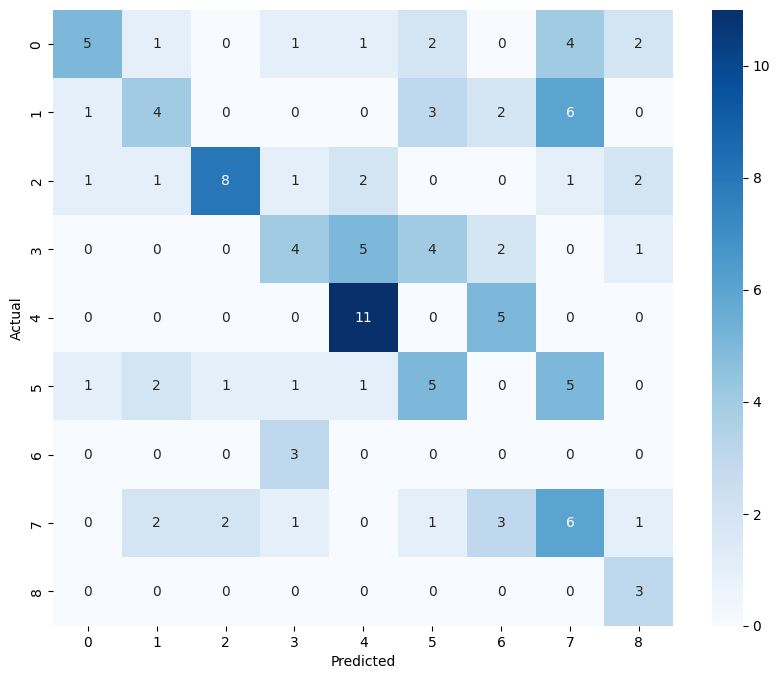

In [39]:

cm=confusion_matrix(y_true,y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


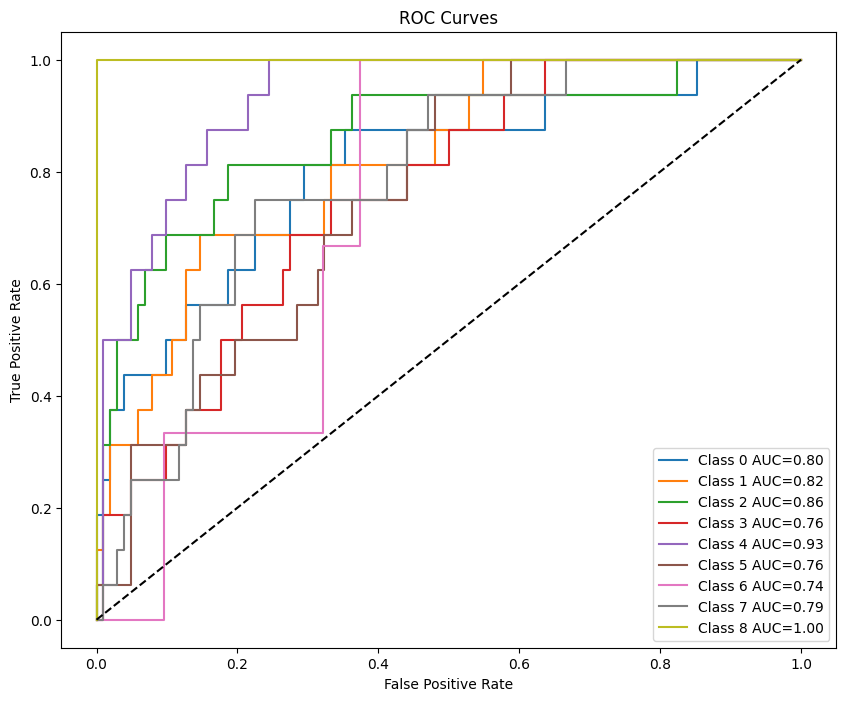

In [40]:

y_true_bin = label_binarize(y_true, classes=range(NUM_CLASSES))

plt.figure(figsize=(10,8))

for i in range(NUM_CLASSES):
    fpr,tpr,_ = roc_curve(y_true_bin[:,i], y_pred_prob[:,i])
    roc_auc = auc(fpr,tpr)
    plt.plot(fpr,tpr,label=f'Class {i} AUC={roc_auc:.2f}')

plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.show()


In [41]:
loss, acc = model.evaluate(test_generator)
print(f"Test Loss: {loss}")
print(f"Test Accuracy: {acc*100:.2f}%")

8/8 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.3644 - loss: 1.8889
Test Loss: 1.8889012336730957
Test Accuracy: 36.44%
